# BMW Global Sales Analysis and Forecasting (2018–2025)

This project analyzes BMW global sales data to identify sales trends,
market performance, and economic factors affecting car sales.
We also build machine learning models to predict future sales."

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

In [2]:
# visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("/kaggle/input/datasets/dmahajanbe23/bmw-global-automotive-sales/bmw_global_sales_2018_2025.csv")
df.head(35)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
5,2018,1,Europe,i4,10607,64082,679717774,0.035,19.12,3.50,1.00
6,2018,1,Europe,iX,4805,73975,355449875,0.016,19.12,3.50,1.00
7,2018,1,Europe,MINI,2554,43005,109834770,0.013,19.12,3.50,1.00
8,2018,1,China,3 Series,3826,48068,183908168,0.021,17.60,2.37,1.02
9,2018,1,China,5 Series,7498,62435,468137630,0.015,17.60,2.37,1.02


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [5]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [6]:
df[['Units_Sold','Avg_Price_EUR','Revenue_EUR']].describe()

,Units_Sold,Avg_Price_EUR,Revenue_EUR
count,3072.000000,3072.000000,3.072000e+03
mean,7980.288086,63854.561523,5.113995e+08
std,3174.917444,14655.891299,2.431185e+08
min,2379.000000,40011.000000,1.045314e+08
25%,5225.500000,54500.250000,3.125504e+08
50%,7985.500000,63493.000000,4.808690e+08
75%,10528.250000,71489.500000,6.709141e+08
max,15914.000000,93994.000000,1.433482e+09


In [7]:
df.sample(5)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
290,2018,10,Europe,X3,3713,57555,213701715,0.017,16.95,3.33,0.96
1234,2021,3,USA,X3,8421,57262,482203302,0.090,19.64,1.71,1.11
2546,2024,8,USA,X3,3799,56731,215521069,0.151,19.86,1.72,1.32
1302,2021,5,USA,iX,4513,74833,337721329,0.091,15.82,3.53,1.12
616,2019,8,China,3 Series,3546,47155,167211630,0.042,20.14,2.55,1.03


In [8]:
#missing values
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [9]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Year                  int64
Month                 int64
Region               object
Model                object
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object

In [11]:
#unique values and value counts
df['Region'].unique()
df['Region'].value_counts()


Region
Europe         768
China          768
USA            768
RestOfWorld    768
Name: count, dtype: int64

In [12]:
df['Model'].unique()
df['Model'].value_counts()

Model
3 Series    384
5 Series    384
X3          384
X5          384
X7          384
i4          384
iX          384
MINI        384
Name: count, dtype: int64

In [13]:
#revenue validation

df["Calculated_Revenue"] = df["Units_Sold"] * df["Avg_Price_EUR"]

difference = df["Revenue_EUR"] - df["Calculated_Revenue"]

print(difference.mean())

0.0


In [14]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,371404204
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,634121800
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,181434465
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,504226100
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,782150200


In [15]:
#date feature
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)
df = df.sort_values("Date")
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01
31,2018,1,RestOfWorld,MINI,9570,42278,404600460,0.000,6.28,4.18,0.97,404600460,2018-01-01
30,2018,1,RestOfWorld,iX,9412,74757,703612884,0.021,6.28,4.18,0.97,703612884,2018-01-01
29,2018,1,RestOfWorld,i4,3194,65790,210133260,0.010,6.28,4.18,0.97,210133260,2018-01-01
28,2018,1,RestOfWorld,X7,7252,93762,679962024,0.018,6.28,4.18,0.97,679962024,2018-01-01


# Exploraotory Data Analysis

In [16]:
#Global sales Trend

sales_trend = df.groupby("Date")["Units_Sold"].sum().reset_index()

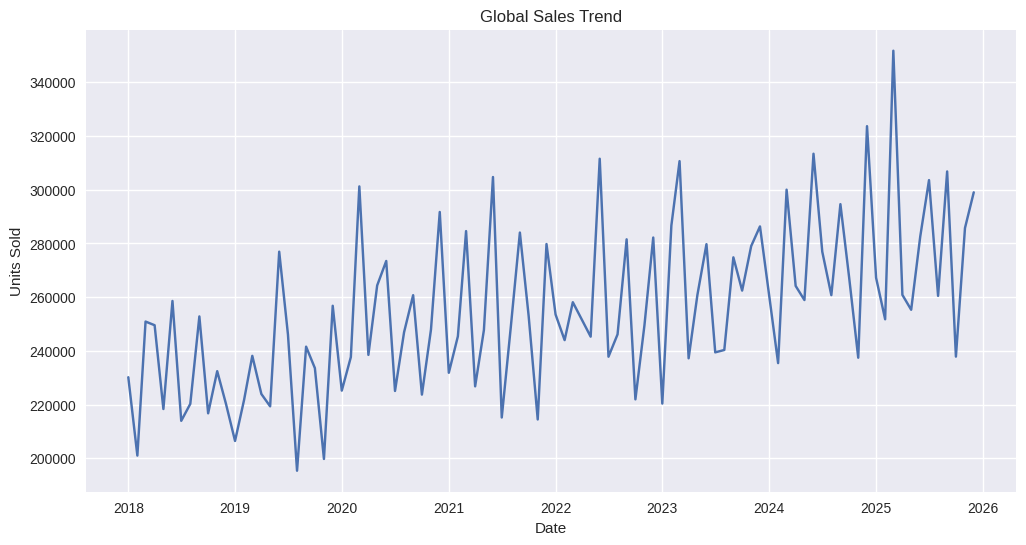

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_trend, x="Date", y="Units_Sold")

plt.title("Global Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

In [18]:
#Revenue Trend
revenue_trend = df.groupby("Date")["Revenue_EUR"].sum().reset_index()


In [19]:
revenue_trend["Revenue_Billion"] = revenue_trend["Revenue_EUR"] / 1e9

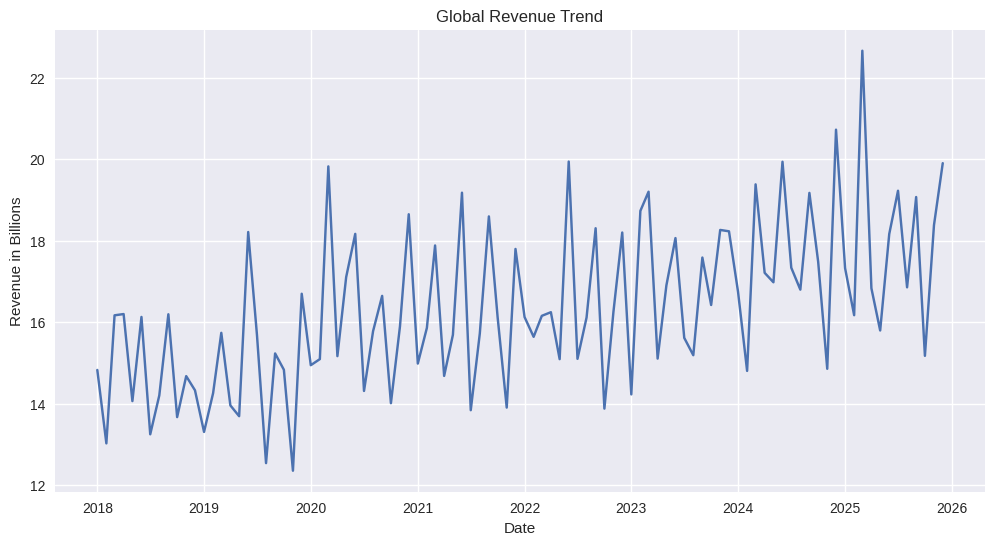

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=revenue_trend, x="Date", y="Revenue_Billion")

plt.title("Global Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue in Billions")
plt.show()

In [21]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index', 'Calculated_Revenue', 'Date'],
      dtype='object')

In [23]:
df.describe

<bound method NDFrame.describe of       Year  Month       Region     Model  Units_Sold  Avg_Price_EUR  \
0     2018      1       Europe  3 Series        7822          47482   
31    2018      1  RestOfWorld      MINI        9570          42278   
30    2018      1  RestOfWorld        iX        9412          74757   
29    2018      1  RestOfWorld        i4        3194          65790   
28    2018      1  RestOfWorld        X7        7252          93762   
...    ...    ...          ...       ...         ...            ...   
3041  2025     12       Europe  5 Series       13150          62228   
3040  2025     12       Europe  3 Series       10588          46966   
3070  2025     12  RestOfWorld        iX        7871          73867   
3054  2025     12        China        iX       11861          74849   
3071  2025     12  RestOfWorld      MINI        6732          41811   

      Revenue_EUR  BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  \
0       371404204      0.011        

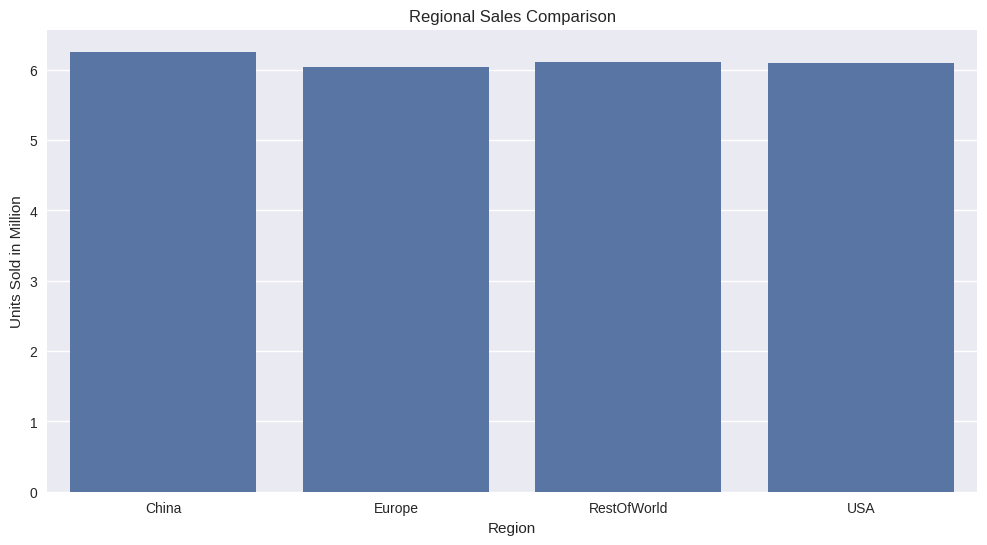

In [24]:
#Sales by regions
regional_sales = df.groupby("Region")["Units_Sold"].sum().reset_index()
regional_sales["Units_Million"] = regional_sales["Units_Sold"] / 1e6

plt.figure(figsize=(12, 6))

sns.barplot(data=regional_sales, x="Region", y="Units_Million")

plt.title("Regional Sales Comparison")
plt.xlabel("Region")
plt.ylabel("Units Sold in Million")
plt.show()

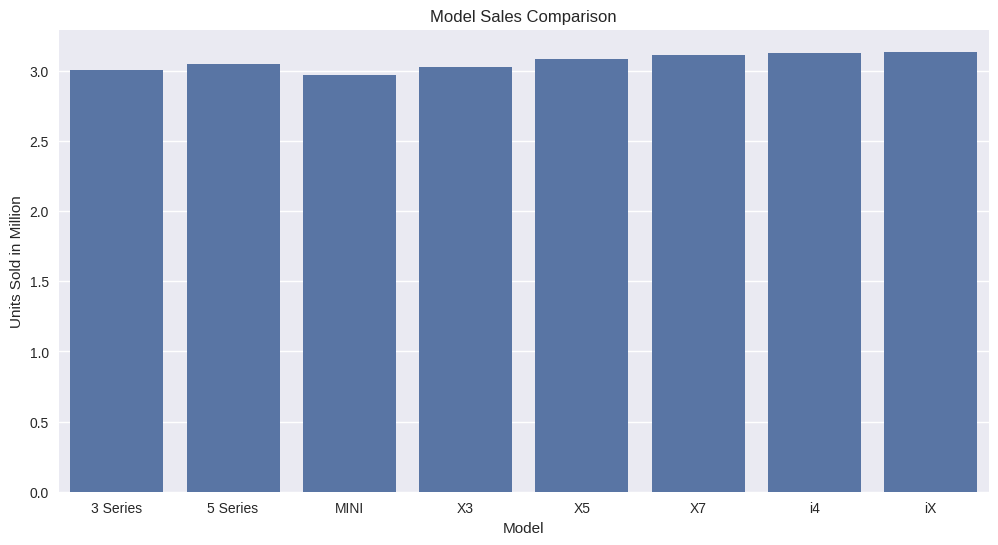

In [25]:
#sales by model
model_sales = df.groupby("Model")["Units_Sold"].sum().reset_index()
model_sales["Units_Million"] = model_sales["Units_Sold"] / 1e6

plt.figure(figsize=(12, 6))

sns.barplot(data=model_sales, x="Model", y="Units_Million")

plt.title("Model Sales Comparison")
plt.xlabel("Model")
plt.ylabel("Units Sold in Million")
plt.show()

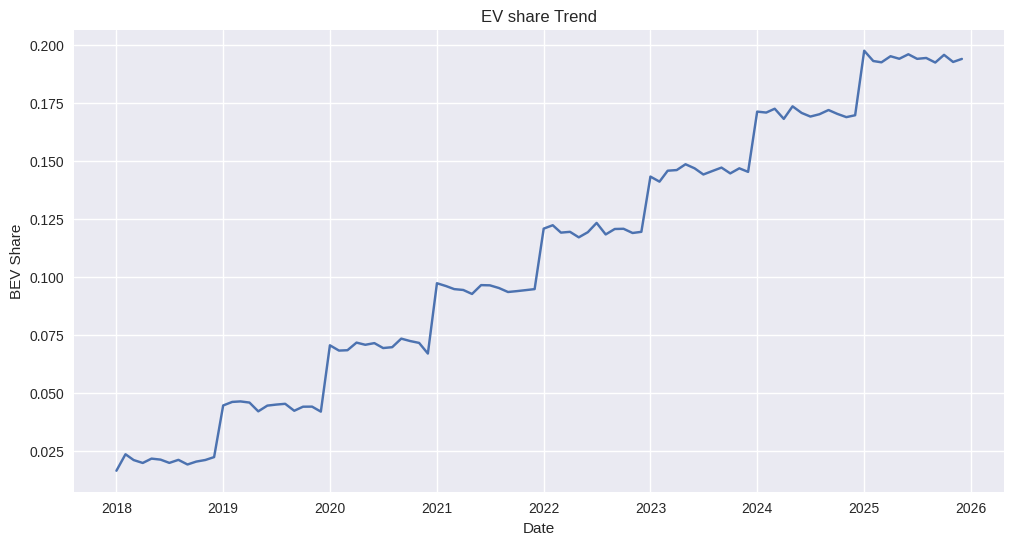

In [26]:
#Ev adoption trend
ev_trend = df.groupby("Date")["BEV_Share"].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=ev_trend, x="Date", y="BEV_Share")

plt.title("EV share Trend")
plt.xlabel("Date")
plt.ylabel("BEV Share")
plt.show()

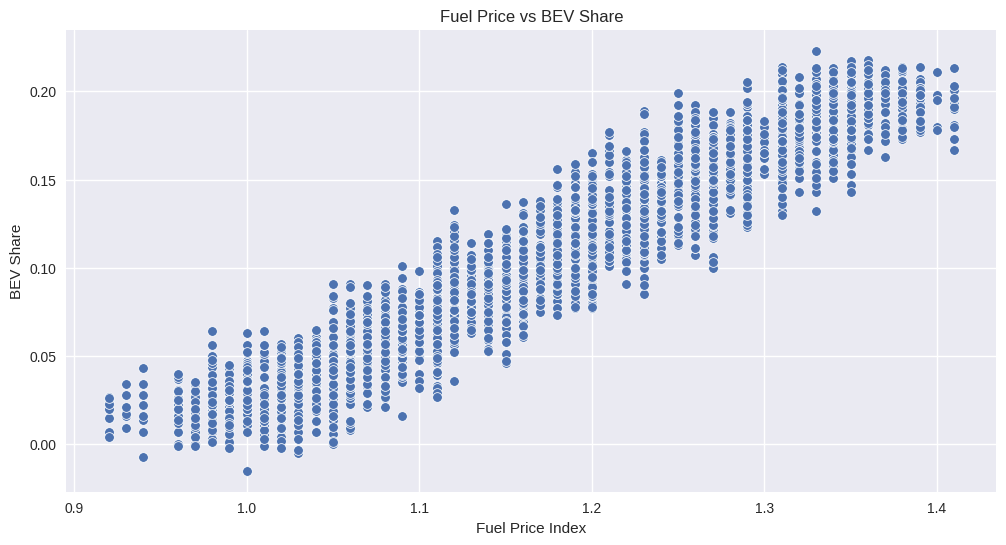

In [27]:
#fuel price vs Ev share

plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x="Fuel_Price_Index", y="BEV_Share")

plt.title("Fuel Price vs BEV Share")
plt.xlabel("Fuel Price Index")
plt.ylabel("BEV Share")
plt.show()

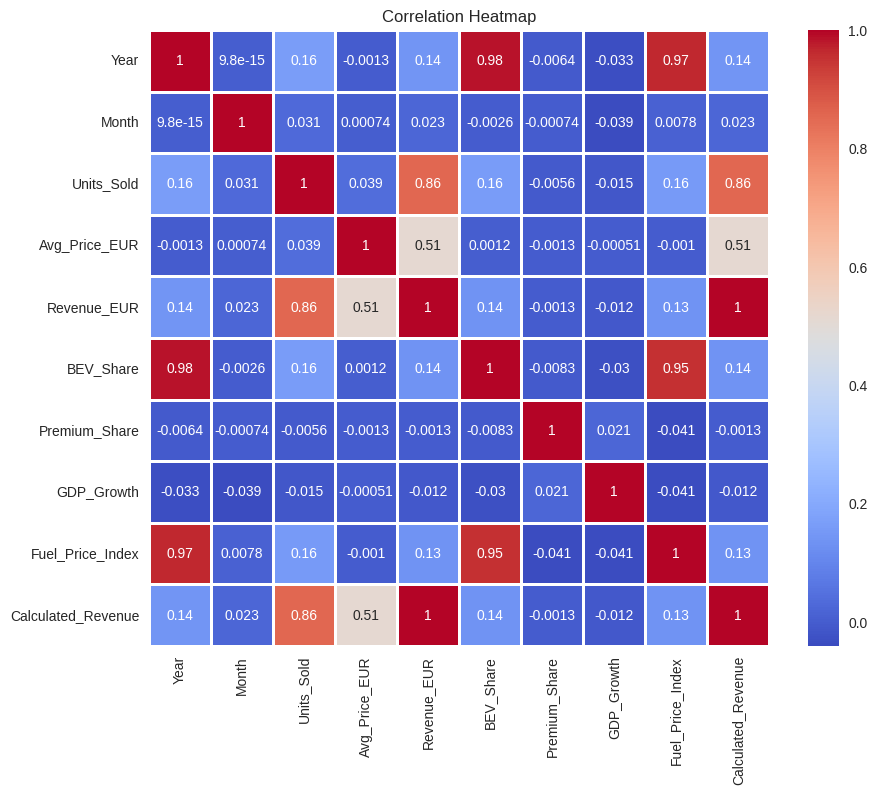

In [28]:
#correlation heatmap
num_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", linewidths=1)
plt.title("Correlation Heatmap")
plt.show()


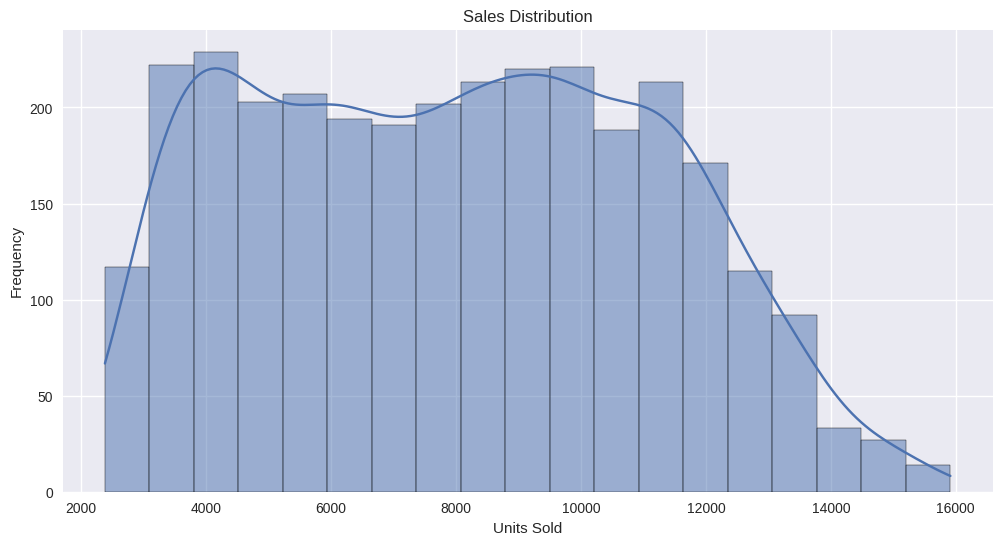

In [29]:
#sales distribution

plt.figure(figsize=(12, 6))

sns.histplot(data=df, x="Units_Sold", kde=True)

plt.title("Sales Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

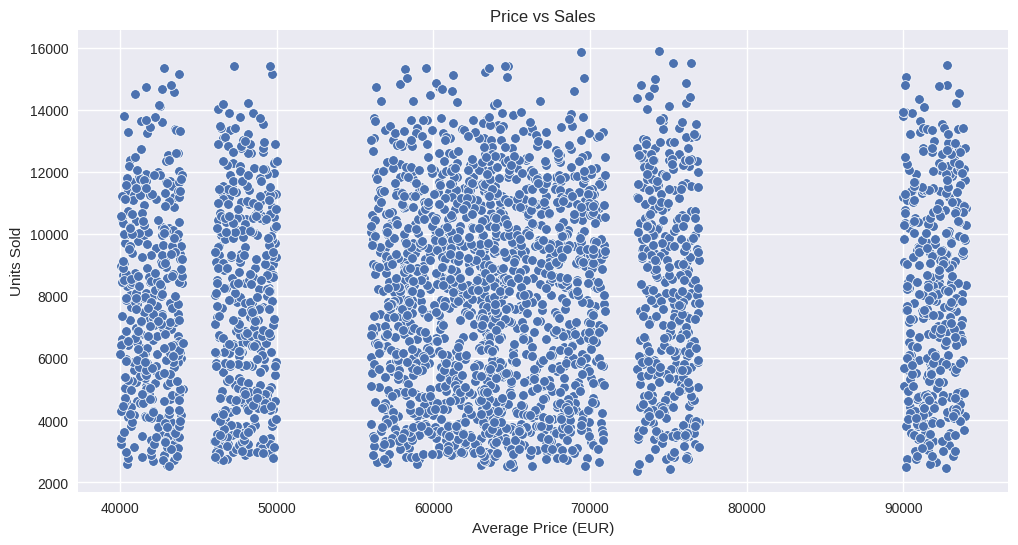

In [30]:
#price vs sales

plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x="Avg_Price_EUR", y="Units_Sold")

plt.title("Price vs Sales")
plt.xlabel("Average Price (EUR)")
plt.ylabel("Units Sold")
plt.show()

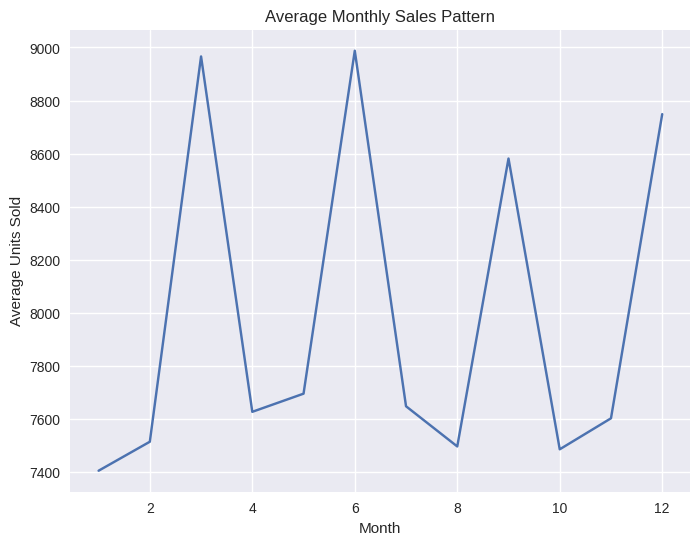

In [31]:
#monthly sales pattern

monthly_sales = df.groupby("Month")["Units_Sold"].mean()

plt.figure(figsize=(8,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Average Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.show()

# Feature Engineering

In [32]:
df["Quarter"] = df["Date"].dt.quarter
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01,1
31,2018,1,RestOfWorld,MINI,9570,42278,404600460,0.000,6.28,4.18,0.97,404600460,2018-01-01,1
30,2018,1,RestOfWorld,iX,9412,74757,703612884,0.021,6.28,4.18,0.97,703612884,2018-01-01,1
29,2018,1,RestOfWorld,i4,3194,65790,210133260,0.010,6.28,4.18,0.97,210133260,2018-01-01,1
28,2018,1,RestOfWorld,X7,7252,93762,679962024,0.018,6.28,4.18,0.97,679962024,2018-01-01,1


In [33]:
#Revenue Per Unit
df["Revenue_per_unit"] = df["Revenue_EUR"] / df["Units_Sold"]
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter,Revenue_per_unit
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01,1,47482.0
31,2018,1,RestOfWorld,MINI,9570,42278,404600460,0.000,6.28,4.18,0.97,404600460,2018-01-01,1,42278.0
30,2018,1,RestOfWorld,iX,9412,74757,703612884,0.021,6.28,4.18,0.97,703612884,2018-01-01,1,74757.0
29,2018,1,RestOfWorld,i4,3194,65790,210133260,0.010,6.28,4.18,0.97,210133260,2018-01-01,1,65790.0
28,2018,1,RestOfWorld,X7,7252,93762,679962024,0.018,6.28,4.18,0.97,679962024,2018-01-01,1,93762.0


In [34]:
#Lag features

df = df.sort_values("Date")

df["Sales_Lag_1"] = df["Units_Sold"].shift(1)
df["Sales_Lag_3"] = df["Units_Sold"].shift(3)
df["Sales_Lag_6"] = df["Units_Sold"].shift(6)

df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter,Revenue_per_unit,Sales_Lag_1,Sales_Lag_3,Sales_Lag_6
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00,371404204,2018-01-01,1,47482.0,NaN,NaN,NaN
8,2018,1,China,3 Series,3826,48068,183908168,0.021,17.60,2.37,1.02,183908168,2018-01-01,1,48068.0,7822.0,NaN,NaN
13,2018,1,China,i4,5369,64955,348743395,0.009,17.60,2.37,1.02,348743395,2018-01-01,1,64955.0,3826.0,NaN,NaN
12,2018,1,China,X7,9119,90034,821020046,0.020,17.60,2.37,1.02,821020046,2018-01-01,1,90034.0,5369.0,7822.0,NaN
11,2018,1,China,X5,8298,68390,567500220,0.017,17.60,2.37,1.02,567500220,2018-01-01,1,68390.0,9119.0,3826.0,NaN


In [35]:
#Rolling sales average

df["Sales_Rolling_3"] = df["Units_Sold"].rolling(3).mean()
df["Sales_Rolling_6"] = df["Units_Sold"].rolling(6).mean()
df[['Sales_Rolling_3', "Sales_Rolling_6"]]

,Sales_Rolling_3,Sales_Rolling_6
0,NaN,NaN
8,NaN,NaN
13,5672.333333,NaN
12,6104.666667,NaN
11,7595.333333,NaN
...,...,...
3057,10135.000000,10045.833333
3061,9380.000000,10955.500000
3054,11863.000000,10729.000000
3055,9383.666667,9759.333333


In [36]:
#Sales Growth rate

df["Sales_Growth"] = df["Units_Sold"].pct_change()
df["Sales_Growth"]

0            NaN
8      -0.510867
13      0.403293
12      0.698454
11     -0.090032
          ...   
3057    2.029012
3061   -0.224484
3054    0.144442
3055   -0.500379
3071    0.136011
Name: Sales_Growth, Length: 3072, dtype: float64

In [37]:
#Ev demand indicator

df["EV_Demand_Index"] = df["BEV_Share"] * df["Fuel_Price_Index"]
df["EV_Demand_Index"]

0       0.01100
8       0.02142
13      0.00918
12      0.02040
11      0.01734
         ...   
3057    0.27472
3061    0.25840
3054    0.26999
3055    0.25270
3071    0.23547
Name: EV_Demand_Index, Length: 3072, dtype: float64

In [38]:
df = df.dropna()

df.shape

(3066, 22)

In [39]:
df.isnull().sum()

Year                  0
Month                 0
Region                0
Model                 0
Units_Sold            0
Avg_Price_EUR         0
Revenue_EUR           0
BEV_Share             0
Premium_Share         0
GDP_Growth            0
Fuel_Price_Index      0
Calculated_Revenue    0
Date                  0
Quarter               0
Revenue_per_unit      0
Sales_Lag_1           0
Sales_Lag_3           0
Sales_Lag_6           0
Sales_Rolling_3       0
Sales_Rolling_6       0
Sales_Growth          0
EV_Demand_Index       0
dtype: int64

In [40]:
df.to_csv("cleaned_bmw_sales_data.csv", index=False)

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

In [45]:
df

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Calculated_Revenue,Date,Quarter,Revenue_per_unit,Sales_Lag_1,Sales_Lag_3,Sales_Lag_6,Sales_Rolling_3,Sales_Rolling_6,Sales_Growth,EV_Demand_Index
9,2018,1,China,5 Series,7498,62435,468137630,0.015,17.60,2.37,1.02,468137630,2018-01-01,1,62435.0,10727.0,9119.0,7822.0,8841.000000,7472.833333,-0.301016,0.01530
5,2018,1,Europe,i4,10607,64082,679717774,0.035,19.12,3.50,1.00,679717774,2018-01-01,1,64082.0,7498.0,8298.0,3826.0,9610.666667,8603.000000,0.414644,0.03500
7,2018,1,Europe,MINI,2554,43005,109834770,0.013,19.12,3.50,1.00,109834770,2018-01-01,1,43005.0,10607.0,10727.0,5369.0,6886.333333,8133.833333,-0.759216,0.01300
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00,782150200,2018-01-01,1,92300.0,2554.0,7498.0,9119.0,7211.666667,8026.333333,2.317933,0.03500
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00,504226100,2018-01-01,1,67955.0,8474.0,10607.0,8298.0,6149.333333,7880.000000,-0.124380,0.02100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3057,2025,12,USA,5 Series,13364,61973,828207172,0.202,18.91,2.54,1.36,828207172,2025-12-01,4,61973.0,4412.0,11744.0,4468.0,10135.000000,10045.833333,2.029012,0.27472
3061,2025,12,USA,i4,10364,66285,686977740,0.190,18.91,2.54,1.36,686977740,2025-12-01,4,66285.0,13364.0,12629.0,4906.0,9380.000000,10955.500000,-0.224484,0.25840
3054,2025,12,China,iX,11861,74849,887783989,0.203,14.38,2.72,1.33,887783989,2025-12-01,4,74849.0,10364.0,4412.0,13220.0,11863.000000,10729.000000,0.144442,0.26999
3055,2025,12,China,MINI,5926,40388,239339288,0.190,14.38,2.72,1.33,239339288,2025-12-01,4,40388.0,11861.0,13364.0,11744.0,9383.666667,9759.333333,-0.500379,0.25270


In [46]:
# Drop rows where target is missing
df = df.dropna(subset=["Revenue_EUR"])

# Fill lag features with 0 (or median — adjust as needed)
lag_cols = ["Sales_Lag_1", "Sales_Lag_3", "Sales_Lag_6"]
df[lag_cols] = df[lag_cols].fillna(0)

In [47]:
# Encode categorical columns
le_region = LabelEncoder()
le_model  = LabelEncoder()
df["Region_enc"] = le_region.fit_transform(df["Region"])
df["Model_enc"]  = le_model.fit_transform(df["Model"])


In [48]:
FEATURES = [
    "Year", "Month", "Quarter",
    "Region_enc", "Model_enc",
    "Units_Sold", "Avg_Price_EUR",
    "BEV_Share", "Premium_Share",
    "GDP_Growth", "Fuel_Price_Index",
    "Sales_Lag_1", "Sales_Lag_3", "Sales_Lag_6",
]


In [49]:
TARGET = "Revenue_EUR"

In [50]:
X = df[FEATURES]
y = df[TARGET]

In [51]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [52]:
# Scale for Linear Regression
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [53]:
# ─────────────────────────────────────────────
# 3. EVALUATION HELPER
# ─────────────────────────────────────────────

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE  : €{mae:,.0f}")
    print(f"  RMSE : €{rmse:,.0f}")
    print(f"  R²   : {r2:.4f}")
    return model, preds


In [54]:

# ─────────────────────────────────────────────
# 4. TRAIN MODELS
# ─────────────────────────────────────────────

print("\n🚗 BMW Sales Revenue Prediction — Model Comparison\n")

# --- Linear Regression ---
lr = LinearRegression()
lr, lr_preds = evaluate(
    "Linear Regression",
    lr, X_train_sc, X_test_sc, y_train, y_test
)



🚗 BMW Sales Revenue Prediction — Model Comparison


  Linear Regression
  MAE  : €33,669,875
  RMSE : €49,552,668
  R²   : 0.9578


In [55]:
# --- Random Forest ---
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf, rf_preds = evaluate(
    "Random Forest Regressor",
    rf, X_train, X_test, y_train, y_test
)


  Random Forest Regressor
  MAE  : €6,486,164
  RMSE : €9,921,365
  R²   : 0.9983


In [56]:
# --- XGBoost ---
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model, xgb_preds = evaluate(
    "XGBoost Regressor",
    xgb_model, X_train, X_test, y_train, y_test
)


  XGBoost Regressor
  MAE  : €6,913,766
  RMSE : €10,819,504
  R²   : 0.9980


In [58]:
# ─────────────────────────────────────────────
# 5. FEATURE IMPORTANCE (XGBoost)
# ─────────────────────────────────────────────

print("\n📊 Top Feature Importances (XGBoost):")
importances = pd.Series(
    xgb_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
for feat, score in importances.items():
    bar = "█" * int(score * 100)
    print(f"  {feat:<22} {score:.4f}  {bar}")



📊 Top Feature Importances (XGBoost):
  Units_Sold             0.6601  ██████████████████████████████████████████████████████████████████
  Avg_Price_EUR          0.2027  ████████████████████
  Model_enc              0.1015  ██████████
  Fuel_Price_Index       0.0064  
  BEV_Share              0.0063  
  Sales_Lag_1            0.0042  
  Region_enc             0.0037  
  Month                  0.0037  
  Premium_Share          0.0030  
  GDP_Growth             0.0029  
  Sales_Lag_6            0.0023  
  Sales_Lag_3            0.0017  
  Year                   0.0013  
  Quarter                0.0001  


In [59]:
# ─────────────────────────────────────────────
# 6. CROSS-VALIDATION (XGBoost — best model)
# ─────────────────────────────────────────────

print("\n🔁 5-Fold Cross-Validation R² (XGBoost):")
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring="r2")
print(f"  Scores : {cv_scores.round(4)}")
print(f"  Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")




🔁 5-Fold Cross-Validation R² (XGBoost):
  Scores : [0.9978 0.9987 0.9987 0.9982 0.9939]
  Mean R²: 0.9975 ± 0.0018


In [60]:
# ─────────────────────────────────────────────
# 7. PREDICT ON NEW DATA
# ─────────────────────────────────────────────

print("\n🔮 Example Prediction (XGBoost):")
new_record = pd.DataFrame([{
    "Year": 2024, "Month": 6, "Quarter": 2,
    "Region_enc": le_region.transform(["Europe"])[0],
    "Model_enc":  le_model.transform(["X5"])[0],
    "Units_Sold": 950, "Avg_Price_EUR": 72000,
    "BEV_Share": 0.035, "Premium_Share": 20.5,
    "GDP_Growth": 1.8, "Fuel_Price_Index": 1.15,
    "Sales_Lag_1": 880, "Sales_Lag_3": 850, "Sales_Lag_6": 800,
}])
predicted_revenue = xgb_model.predict(new_record)[0]
print(f"  Predicted Revenue: €{predicted_revenue:,.0f}")

print("\n✅ Done! Best model for deployment: XGBoost\n")


🔮 Example Prediction (XGBoost):
  Predicted Revenue: €186,144,608

✅ Done! Best model for deployment: XGBoost

